<h1 align="center">Assignment 3: Understanding Customer Tipping Behavior</h1>

## Q1: Loading and Understanding the Dataset (10 marks)

In [44]:
# import libs

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import warnings
warnings.filterwarnings('ignore')

In [6]:
# Q1.1: Load dataset

df = sns.load_dataset("tips")

In [7]:
# Q1.2: Display first rows

df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [8]:
# Q1.3: Dataset shape and columns

print(df.shape)
print(df.columns)

(244, 7)
Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='object')


## Q2: Basic Filtering – Who Tips More? (25 marks)

In [19]:
#Q2.1: Weekend
weekend_df = df[(df["day"] == "Sun") | (df["day"] == "Sat")]

In [20]:
# Weekday
weekday_df = df[(df["day"] != "Sun") & (df["day"] != "Sat")]

In [21]:
# Q2.2:Average tip, Average total bill

print(f"Average weekend bill: {weekend_df.tip.mean()}")
print(f"Average weekend total bill: {weekend_df.total_bill.mean()}\n")

print(f"Average weekday bill: {weekday_df.tip.mean()}")
print(f"Average weekday total bill: {weekday_df.total_bill.mean()}")

Average weekend bill: 3.115276073619632
Average weekend total bill: 20.893006134969326

Average weekday bill: 2.7628395061728392
Average weekday total bill: 17.55814814814815


### Answer Q2.3: Compare this with weekday customers.

Average **bill** and **total bill** is greater on **weekend** days (San, Sat) than on **weekday**

## Q3: Sorting and Identifying High-Value Customers (15 marks)

In [22]:
# Q3.1: Sort customers by total_bill (descending).

df.sort_values("total_bill", ascending=False)

,total_bill,tip,sex,smoker,day,time,size
170,50.81,10.00,Male,Yes,Sat,Dinner,3
212,48.33,9.00,Male,No,Sat,Dinner,4
59,48.27,6.73,Male,No,Sat,Dinner,4
156,48.17,5.00,Male,No,Sun,Dinner,6
182,45.35,3.50,Male,Yes,Sun,Dinner,3
...,...,...,...,...,...,...,...
149,7.51,2.00,Male,No,Thur,Lunch,2
111,7.25,1.00,Female,No,Sat,Dinner,1
172,7.25,5.15,Male,Yes,Sun,Dinner,2
92,5.75,1.00,Female,Yes,Fri,Dinner,2


In [30]:
# Q3.2:Display the top 10 highest bills.

print(df.sort_values("total_bill", ascending=False).head(10)["size"].mean())
df.sort_values("total_bill", ascending=False).head(10)

3.8


,total_bill,tip,sex,smoker,day,time,size
170,50.81,10.00,Male,Yes,Sat,Dinner,3
212,48.33,9.00,Male,No,Sat,Dinner,4
59,48.27,6.73,Male,No,Sat,Dinner,4
156,48.17,5.00,Male,No,Sun,Dinner,6
182,45.35,3.50,Male,Yes,Sun,Dinner,3
102,44.30,2.50,Female,Yes,Sat,Dinner,3
197,43.11,5.00,Female,Yes,Thur,Lunch,4
142,41.19,5.00,Male,No,Thur,Lunch,5
184,40.55,3.00,Male,Yes,Sun,Dinner,2
95,40.17,4.73,Male,Yes,Fri,Dinner,4


### Answer Q3.3: What do you notice about their group sizes?

There is no groups of size 1 in top 10 highest bills. Also, **tital_bill** and **tip** do not strongly depend on the **size**. It has weak correlation.

## Q4: Data Quality Check & Cleaning (10 marks)

In [37]:
# Q4.1: missing values

df.isna().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

### Answer Q4.2: Why missing values are dangerous in machine learning.

<p>It affect data, quality and prediction accuracy. Also it affects statistical values, such as mean (average), correlation and so on.</p>

## Q5: Visualization – What Influences Tips? (25 marks)

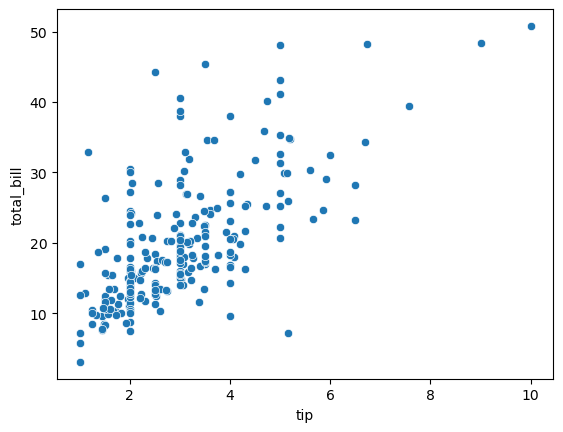

In [40]:
# Q5.1: Tip vs Total Bill (scatter plot)

sns.scatterplot(x="tip", y="total_bill", data=df)

plt.show()

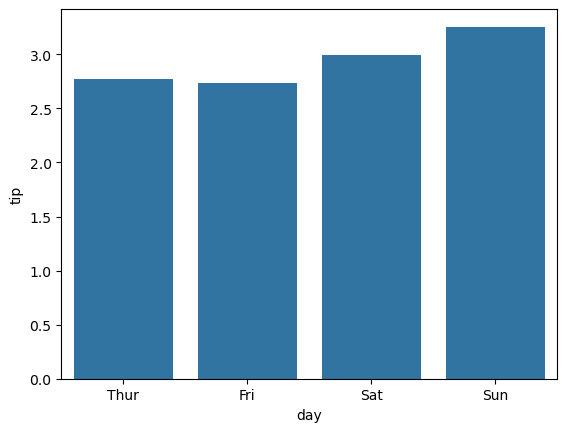

In [45]:
#  Q5.1: Average tip by day (bar plot)

avg_tip_by_day = df.groupby("day")["tip"].mean()

sns.barplot(x = avg_tip_by_day.index, y = avg_tip_by_day.values)
plt.ylabel("tip")
plt.show()

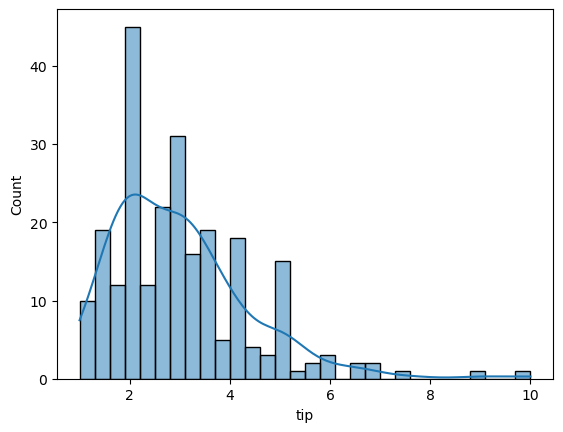

In [47]:
# Q5.1: Tip distribution (histogram)

sns.histplot(df.tip, bins=30, kde=True)
plt.show()

### Answer Q5.2: Interpret each plot in 1–2 sentences.

<h4>Tip vs Total Bill</h4>
We have positive correlation between tip and total bill, but there is high deviation.

<h4>Average tip by day</h4>
On weekends tips is slightly larger than on weekdays.

<h4>Tip distribution</h4>
The most customers leave from 2\$ to 5\$ tips.

## Q6: Final Insight & Conclusion (25 marks)


In [49]:
df.sort_values("tip", ascending=False).head(15)

,total_bill,tip,sex,smoker,day,time,size
170,50.81,10.00,Male,Yes,Sat,Dinner,3
212,48.33,9.00,Male,No,Sat,Dinner,4
23,39.42,7.58,Male,No,Sat,Dinner,4
59,48.27,6.73,Male,No,Sat,Dinner,4
141,34.30,6.70,Male,No,Thur,Lunch,6
214,28.17,6.50,Female,Yes,Sat,Dinner,3
183,23.17,6.50,Male,Yes,Sun,Dinner,4
47,32.40,6.00,Male,No,Sun,Dinner,4
239,29.03,5.92,Male,No,Sat,Dinner,3
88,24.71,5.85,Male,No,Thur,Lunch,2


- **Non-smoking males** tips more.
- The tips are highest on **weekends** in **dinner time**
- These insights help restaurant management schedule more stuff on weekends and dinner time, focus on high-value customers, and improve service quality during peak hours to increase revenue and tips